# March Machine Learning Mania 2026 - Baseline Model Training

Bu notebook'ta LightGBM kullanarak baseline model eÄŸiteceÄŸiz.

**Plan:**
1. Veri yÃ¼kleme
2. Train/Val split (walk-forward)
3. LightGBM model eÄŸitimi
4. Performans deÄŸerlendirme (Brier Score, AUC)
5. Feature importance analizi

## Cell 1: Imports ve Setup

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# GÃ¶rÃ¼ntÃ¼leme ayarlarÄ±
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# TÃ¼m sÃ¼tunlarÄ± gÃ¶ster
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("âœ… TÃ¼m kÃ¼tÃ¼phaneler yÃ¼klendi!")
print(f"\nPython versiyonlarÄ±:")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  lightgbm: {lgb.__version__}")

âœ… TÃ¼m kÃ¼tÃ¼phaneler yÃ¼klendi!

Python versiyonlarÄ±:
  pandas: 3.0.1
  numpy: 2.4.2
  lightgbm: 4.6.0


## Cell 2: Veri YÃ¼kleme

Feature engineering pipeline'Ä±ndan Ã§Ä±kan processed CSV'leri yÃ¼klÃ¼yoruz.

In [2]:
# Veri yÃ¼kleme
men = pd.read_csv("../artifacts/data/processed_features_men.csv")
women = pd.read_csv("../artifacts/data/processed_features_women.csv")

print("=" * 60)
print("VERÄ° SETÄ° BÄ°LGÄ°LERÄ°")
print("=" * 60)
print(f"\nErkekler:")
print(f"  Toplam satÄ±r: {len(men):,}")
print(f"  Toplam sÃ¼tun: {len(men.columns)}")
print(f"  Season aralÄ±ÄŸÄ±: {men['Season'].min()} - {men['Season'].max()}")
print(f"  Target balance: {men['Target'].mean():.3f} (0.5 = dengeli)")

print(f"\nKadÄ±nlar:")
print(f"  Toplam satÄ±r: {len(women):,}")
print(f"  Toplam sÃ¼tun: {len(women.columns)}")
print(f"  Season aralÄ±ÄŸÄ±: {women['Season'].min()} - {women['Season'].max()}")
print(f"  Target balance: {women['Target'].mean():.3f} (0.5 = dengeli)")

# Ä°lk birkaÃ§ satÄ±rÄ± gÃ¶ster
print("\n" + "=" * 60)
print("ERKEKLER - Ä°lk 5 satÄ±r:")
print("=" * 60)
display(men.head())

VERÄ° SETÄ° BÄ°LGÄ°LERÄ°

Erkekler:
  Toplam satÄ±r: 2,898
  Toplam sÃ¼tun: 62
  Season aralÄ±ÄŸÄ±: 2003 - 2025
  Target balance: 0.500 (0.5 = dengeli)

KadÄ±nlar:
  Toplam satÄ±r: 1,922
  Toplam sÃ¼tun: 57
  Season aralÄ±ÄŸÄ±: 2010 - 2025
  Target balance: 0.500 (0.5 = dengeli)

ERKEKLER - Ä°lk 5 satÄ±r:


,Season,TeamA,TeamB,Target,Split,WinPct_diff,AvgScore_diff,AvgOppScore_diff,TotalScore_diff,TrueMarginAvg_diff,ScoreVariance_diff,OTRate_diff,AvgOT_diff,MultiOTRate_diff,CloseWinPct_diff,CloseGamesCount_diff,NetRtg_diff,eFG_diff,TOVpct_diff,ORBpct_diff,FTr_diff,FTr_vs_OppAllowed_diff,StlPct_diff,BlkPct_diff,WinPct_last7_diff,WinPct_last10_diff,WinPct_last14_diff,WinPct_last21_diff,Margin_last7_diff,Margin_last10_diff,Margin_last14_diff,Margin_last21_diff,DaysSinceLastGame_diff,GamesLast7Days_diff,GamesLast14Days_diff,B2B_Last14Days_diff,SeedNum_diff,ConfStrength_diff,ConfWinPct_diff,ConfTeamCount_diff,ConfBidCount_diff,ConfTourneyGamesPlayed_diff,ConfTourneyWinPct_diff,ConfTourneyChampion_diff,DaysSinceConfFinal_diff,CoachTenureYears_diff,ProgramAge_diff,MasseyPct_diff,MasseyAvgRank_diff,Heavy_Favorite,Toss_Up,TeamA_Is_Favorite,TeamA_Is_Underdog,TeamA_Seed_Top4,TeamA_Seed_Mid,TeamA_Seed_Low,TeamA_Is_11_12_vs_5_6,TeamA_Is_5_6_vs_11_12,Round_Num,Is_FirstWeekend,Is_SecondWeekend,Is_FinalWeekend
0,2005,1448,1151,1,Train,0.209080,14.265233,5.863799,20.129032,7.449857,-0.993420,0.064516,0.064516,0.000000,-0.090909,0,11.587017,0.064377,-0.038867,0.013067,0.024725,-0.014689,0.017709,0.021491,0.142857,0.3,0.214286,0.238095,13.714286,13.200,9.104286,9.476190,4.0,-1,-1,-2,-13.0,10.926338,0.152952,-1,4.0,-2.0,-1.000000,-1,-6.0,3,0,0.486322,-154.666667,1,0,1,0,1,0,0,0,0,1,1,0,0
1,2004,1272,1329,0,Train,-0.146552,-4.635468,2.032020,-2.603448,-6.498128,-2.258542,-0.068966,-0.103448,-0.034483,-0.104167,4,-10.117893,-0.060029,-0.010124,0.001382,-0.000844,-0.014214,-0.005152,0.022624,-0.142857,-0.1,-0.071429,-0.095238,2.351429,-3.054,-2.175714,-4.653810,4.0,-1,-1,-2,5.0,-1.446431,-0.015214,2,2.0,-2.0,-1.000000,-1,3.0,-10,0,-0.083077,25.333333,0,0,0,1,0,1,0,0,0,2,1,0,0
2,2010,1320,1242,1,Train,-0.066176,-18.452206,-9.512868,-27.965074,-8.117757,-5.546196,-0.058824,-0.058824,0.000000,0.087302,5,-9.676224,-0.053006,-0.005152,-0.069579,-0.062777,-0.033189,-0.026544,-0.057599,-0.142857,-0.1,-0.142857,-0.047619,-4.714286,-6.046,-5.000000,-4.355238,0.0,0,0,0,8.0,-5.169334,-0.076117,-2,-6.0,0.0,0.000000,0,6.0,-3,0,-0.088150,27.500000,0,0,0,1,0,1,0,0,0,2,1,0,0
3,2007,1172,1268,0,Train,0.120968,0.500000,1.115927,1.615927,1.359536,-2.109515,-0.031250,-0.031250,-0.000000,0.080808,2,-0.602267,-0.002677,-0.013799,-0.008258,-0.062035,-0.063546,0.005371,-0.057786,-0.000000,0.2,0.214286,0.238095,5.494286,11.100,10.110000,4.650000,-4.0,1,2,3,9.0,-13.014007,-0.203799,-1,-6.0,2.0,1.000000,1,5.0,0,0,-0.173134,56.000000,0,0,0,1,0,0,1,0,0,1,1,0,0
4,2015,1279,1462,0,Train,0.007353,-0.933824,-0.147059,-1.080882,-0.828897,1.012193,-0.055147,-0.084559,-0.029412,0.176190,1,-0.887816,-0.047444,-0.017408,0.033385,-0.009676,-0.076820,0.008529,0.012934,-0.285714,-0.1,-0.000000,0.047619,-4.922857,-2.600,-1.071429,2.727143,4.0,-1,0,-1,5.0,-0.767517,-0.022173,4,-1.0,-2.0,-0.666667,0,2.0,3,0,-0.068571,20.333333,0,0,0,1,0,0,1,1,0,1,1,0,0


## Cell 3: Train/Val/Test Split (Walk-Forward)

**Neden Walk-Forward?**
- Time-series veri (yÄ±l yÄ±l ilerliyor)
- GeÃ§miÅŸle eÄŸit, geleceÄŸi tahmin et
- Data leakage'Ä± Ã¶nler

**Split Stratejisi:**
- Train: Season â‰¤ 2022 (geÃ§miÅŸ)
- Val: Season = 2023 (validation)
- Test: Season = 2024 (final test)

In [10]:
def prepare_data(df, gender_label):
    """
    Veriyi train/val/test olarak bÃ¶ler.
    
    Returns:
        X_train, y_train, X_val, y_val, feature_columns
    """
    # Feature columns: tum _diff kolonlar + secili non-diff seed bayraklari
    feature_cols = [c for c in df.columns if c.endswith("_diff")]
    extra_cols = [
        "Heavy_Favorite",
        "TeamA_Is_Favorite",
        "TeamA_Is_Underdog",
        "TeamA_Seed_Top4",
        "TeamA_Seed_Mid",
        "TeamA_Seed_Low",
        "TeamA_Is_11_12_vs_5_6",
        "TeamA_Is_5_6_vs_11_12",
        "Toss_Up",
        "Round_Num",
        "Is_FirstWeekend",
        "Is_SecondWeekend",
        "Is_FinalWeekend",
    ]
    feature_cols += [c for c in extra_cols if c in df.columns]
    feature_cols = list(dict.fromkeys(feature_cols))
    
    # Walk-forward split
    train = df[df["Season"] <= 2022]
    val = df[df["Season"] == 2023]
    test = df[df["Season"] == 2024]
    
    # X ve y ayrÄ±mÄ±
    X_train = train[feature_cols]
    y_train = train["Target"]
    X_val = val[feature_cols]
    y_val = val["Target"]
    X_test = test[feature_cols]
    y_test = test["Target"]
    
    print(f"\n{gender_label} Data Split:")
    print(f"  Train (â‰¤2022): {len(X_train):,} samples")
    print(f"  Val (2023):     {len(X_val):,} samples")
    print(f"  Test (2024):    {len(X_test):,} samples")
    print(f"  Features:       {len(feature_cols)}")
    
    # NaN kontrolÃ¼
    nan_count = X_train.isna().sum().sum()
    if nan_count > 0:
        print(f"  âš ï¸  UyarÄ±: {nan_count} NaN deÄŸer var!")
    else:
        print(f"  âœ… NaN deÄŸer yok")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, feature_cols

# Erkekler iÃ§in hazÄ±rla
X_train_m, y_train_m, X_val_m, y_val_m, X_test_m, y_test_m, features_m = prepare_data(men, "Erkekler")

# KadÄ±nlar iÃ§in hazÄ±rla
X_train_w, y_train_w, X_val_w, y_val_w, X_test_w, y_test_w, features_w = prepare_data(women, "KadÄ±nlar")


Erkekler Data Split:
  Train (â‰¤2022): 2,496 samples
  Val (2023):     134 samples
  Test (2024):    134 samples
  Features:       44
  âœ… NaN deÄŸer yok

KadÄ±nlar Data Split:
  Train (â‰¤2022): 1,520 samples
  Val (2023):     134 samples
  Test (2024):    134 samples
  Features:       39
  âœ… NaN deÄŸer yok


## Cell 4: LightGBM Model TanÄ±mÄ±

**LightGBM Parametreleri AÃ§Ä±klamasÄ±:**

| Parametre | DeÄŸer | AÃ§Ä±klama |
|-----------|-------|----------|
| `objective` | 'binary' | Binary classification (kazanÄ±r/kazanmaz) |
| `metric` | 'binary_logloss' | Log loss minimizasyon |
| `n_estimators` | 500 | 500 karar aÄŸacÄ± |
| `learning_rate` | 0.05 | Her adÄ±mda ne kadar Ã¶ÄŸrenilsin |
| `max_depth` | 6 | AÄŸaÃ§ max derinliÄŸi (overfitting Ã¶nler) |
| `num_leaves` | 31 | Yaprak sayÄ±sÄ± |
| `min_child_samples` | 20 | Her yaprakta min sample (overfitting Ã¶nler) |
| `verbose` | -1 | Ã‡Ä±ktÄ± kapat |

In [17]:
def train_lgbm(X_train, y_train, X_val, y_val, gender_label):
    """
    LightGBM modelini eÄŸitir.
    
    Returns:
        Trained model
    """
    print(f"\n{gender_label} modeli eÄŸitiliyor...")
    
    # Model parametreleri (baseline)
    params = {
        'objective': 'binary',           # Binary classification
        'metric': 'binary_logloss',      # Log loss minimizasyon
        'n_estimators': 500,             # 500 aÄŸaÃ§
        'learning_rate': 0.05,           # Ã–ÄŸrenme hÄ±zÄ±
        'max_depth': 6,                  # AÄŸaÃ§ derinliÄŸi
        'num_leaves': 31,                # Yaprak sayÄ±sÄ±
        'min_child_samples': 20,         # Overfitting Ã¶nleme
        'verbose': -1,                   # Ã‡Ä±ktÄ± kapat
        'random_state': 42               # Reproducibility
    }
    
    # Model oluÅŸtur
    model = lgb.LGBMClassifier(**params)
    
    # EÄŸit (early stopping ile)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    print(f"âœ… {gender_label} modeli eÄŸitildi!")
    print(f"   KullanÄ±lan aÄŸaÃ§ sayÄ±sÄ±: {model.n_estimators_}")
    
    return model

## Cell 5: Model EÄŸitimi

Åimdi hem erkekler hem kadÄ±nlar iÃ§in modelleri eÄŸitiyoruz.

In [23]:
# Erkekler modelini eÄŸit
men_model = train_lgbm(X_train_m, y_train_m, X_val_m, y_val_m, "Erkekler")

# KadÄ±nlar modelini eÄŸit
women_model = train_lgbm(X_train_w, y_train_w, X_val_w, y_val_w, "KadÄ±nlar")

print("\n" + "=" * 60)
print("TÃœM MODELLER EÄÄ°TÄ°LDÄ°!")
print("=" * 60)


Erkekler modeli eÄŸitiliyor...
âœ… Erkekler modeli eÄŸitildi!
   KullanÄ±lan aÄŸaÃ§ sayÄ±sÄ±: 24

KadÄ±nlar modeli eÄŸitiliyor...
âœ… KadÄ±nlar modeli eÄŸitildi!
   KullanÄ±lan aÄŸaÃ§ sayÄ±sÄ±: 25

TÃœM MODELLER EÄÄ°TÄ°LDÄ°!


## Cell 6: Tahmin ve Performans DeÄŸerlendirme

**Metrikler AÃ§Ä±klamasÄ±:**

| Metrik | Ne Ã¶lÃ§er? | Ä°yi yÃ¶n | Hedef |
|--------|----------|---------|-------|
| **Brier Score** | OlasÄ±lÄ±k kalibrasyonu | DÃ¼ÅŸÃ¼k = iyi | < 0.20 |
| **Log Loss** | Probability error | DÃ¼ÅŸÃ¼k = iyi | - |
| **AUC-ROC** | Separation gÃ¼cÃ¼ | YÃ¼ksek = iyi | > 0.75 |

**Brier Score:** `(predicted - actual)Â²` ortalamasÄ±
- Kaggle'Ä±n kullandÄ±ÄŸÄ± metric
- Overconfident tahminler ceza alÄ±r
- 0 = mÃ¼kemmel, 0.25 = random guess, 1 = tam ters

In [24]:
import os

def build_calibration_table(y_true, y_pred_proba, n_bins=10):
    temp = pd.DataFrame({"y_true": y_true.values, "y_pred": y_pred_proba})
    temp["bin"] = pd.qcut(temp["y_pred"], q=n_bins, duplicates="drop")
    calib = (
        temp.groupby("bin", observed=False)
        .agg(
            sample_count=("y_true", "size"),
            pred_mean=("y_pred", "mean"),
            actual_rate=("y_true", "mean"),
        )
        .reset_index()
    )
    calib["abs_gap"] = (calib["pred_mean"] - calib["actual_rate"]).abs()
    return calib

def evaluate_model(model, X_eval, y_eval, gender_label, split_label="Validation"):
    """
    More detailed evaluation metrics for model strength analysis.
    """
    y_pred_proba = model.predict_proba(X_eval)[:, 1]
    y_pred_label = (y_pred_proba >= 0.5).astype(int)

    brier = brier_score_loss(y_eval, y_pred_proba)
    logloss = log_loss(y_eval, y_pred_proba)
    auc = roc_auc_score(y_eval, y_pred_proba)
    accuracy = (y_pred_label == y_eval.values).mean()

    # 0.25 is the Brier baseline for always predicting 0.5 in balanced binary tasks
    brier_skill = 1 - (brier / 0.25)

    actual_win_rate = float(y_eval.mean())
    pred_win_rate = float(y_pred_proba.mean())
    pred_bias = pred_win_rate - actual_win_rate

    mean_pred_when_win = float(y_pred_proba[y_eval.values == 1].mean())
    mean_pred_when_loss = float(y_pred_proba[y_eval.values == 0].mean())
    class_separation = mean_pred_when_win - mean_pred_when_loss

    calib = build_calibration_table(y_eval, y_pred_proba, n_bins=10)
    calib_weighted_mae = float((calib["abs_gap"] * calib["sample_count"]).sum() / calib["sample_count"].sum())

    print(f"\n{'='*70}")
    print(f"{gender_label} - {split_label} METRICS")
    print(f"{'='*70}")
    print(f"Brier Score           : {brier:.4f}")
    print(f"Brier Skill vs 0.5    : {brier_skill:.4f}")
    print(f"Log Loss              : {logloss:.4f}")
    print(f"AUC-ROC               : {auc:.4f}")
    print(f"Accuracy@0.50         : {accuracy:.4f}")
    print(f"Calibration W-MAE     : {calib_weighted_mae:.4f}")
    print(f"Prediction Bias       : {pred_bias:.4f}")
    print(f"Class Separation      : {class_separation:.4f}")
    print(f"Pred Mean / Actual    : {pred_win_rate:.4f} / {actual_win_rate:.4f}")

    metrics = {
        "brier": brier,
        "brier_skill": brier_skill,
        "logloss": logloss,
        "auc": auc,
        "accuracy_at_050": accuracy,
        "calib_weighted_mae": calib_weighted_mae,
        "prediction_bias": pred_bias,
        "class_separation": class_separation,
        "pred_mean": pred_win_rate,
        "actual_mean": actual_win_rate,
    }
    return y_pred_proba, metrics, calib

# Evaluate men
men_pred, men_metrics, men_calib = evaluate_model(men_model, X_val_m, y_val_m, "MEN")

# Evaluate women
women_pred, women_metrics, women_calib = evaluate_model(women_model, X_val_w, y_val_w, "WOMEN")

metrics_summary = pd.DataFrame([
    {"gender": "men", **men_metrics},
    {"gender": "women", **women_metrics},
])

print("\n" + "="*70)
print("METRICS SUMMARY TABLE")
print("="*70)
print(metrics_summary.round(4).to_string(index=False))

report_dir = "../artifacts/models"
os.makedirs(report_dir, exist_ok=True)
metrics_summary.to_csv(f"{report_dir}/baseline_metrics_summary.csv", index=False)
men_calib.to_csv(f"{report_dir}/men_calibration_bins.csv", index=False)
women_calib.to_csv(f"{report_dir}/women_calibration_bins.csv", index=False)

print("\nSaved report files:")
print(f"  - {report_dir}/baseline_metrics_summary.csv")
print(f"  - {report_dir}/men_calibration_bins.csv")
print(f"  - {report_dir}/women_calibration_bins.csv")



ERKEKLER MODEL PERFORMANSI (Validation Set)
  Brier Score:  0.2050  âš ï¸ (hedef: < 0.20)
  Log Loss:     0.5976  (dÃ¼ÅŸÃ¼k = iyi)
  AUC-ROC:      0.7454  âš ï¸ (hedef: > 0.75)

  Probability DaÄŸÄ±lÄ±mÄ±:
    Min: 0.162
    Mean: 0.498
    Max: 0.834

  GerÃ§ek kazanma oranÄ±:  0.500
  Tahmin kazanma oranÄ±:  0.498
  Fark: 0.002 âœ…

KADINLAR MODEL PERFORMANSI (Validation Set)
  Brier Score:  0.1777  âœ… (hedef: < 0.20)
  Log Loss:     0.5302  (dÃ¼ÅŸÃ¼k = iyi)
  AUC-ROC:      0.8155  âœ… (hedef: > 0.75)

  Probability DaÄŸÄ±lÄ±mÄ±:
    Min: 0.138
    Mean: 0.496
    Max: 0.858

  GerÃ§ek kazanma oranÄ±:  0.500
  Tahmin kazanma oranÄ±:  0.496
  Fark: 0.004 âœ…

Ã–ZET KARÅILAÅTIRMA
Metric          Erkekler        KadÄ±nlar       
---------------------------------------------
Brier Score     0.2050          0.1777         
AUC-ROC         0.7454          0.8155         


## Cell 7: Feature Importance Analizi

Hangi feature'lar model iÃ§in en Ã¶nemli? Bu analiz bize:
1. Hangi deÄŸiÅŸkenleri korumalÄ±yÄ±z
2. Hangi deÄŸiÅŸkenleri Ã§Ä±karabiliriz
3. Domain knowledge'Ä±mÄ±z doÄŸru mu

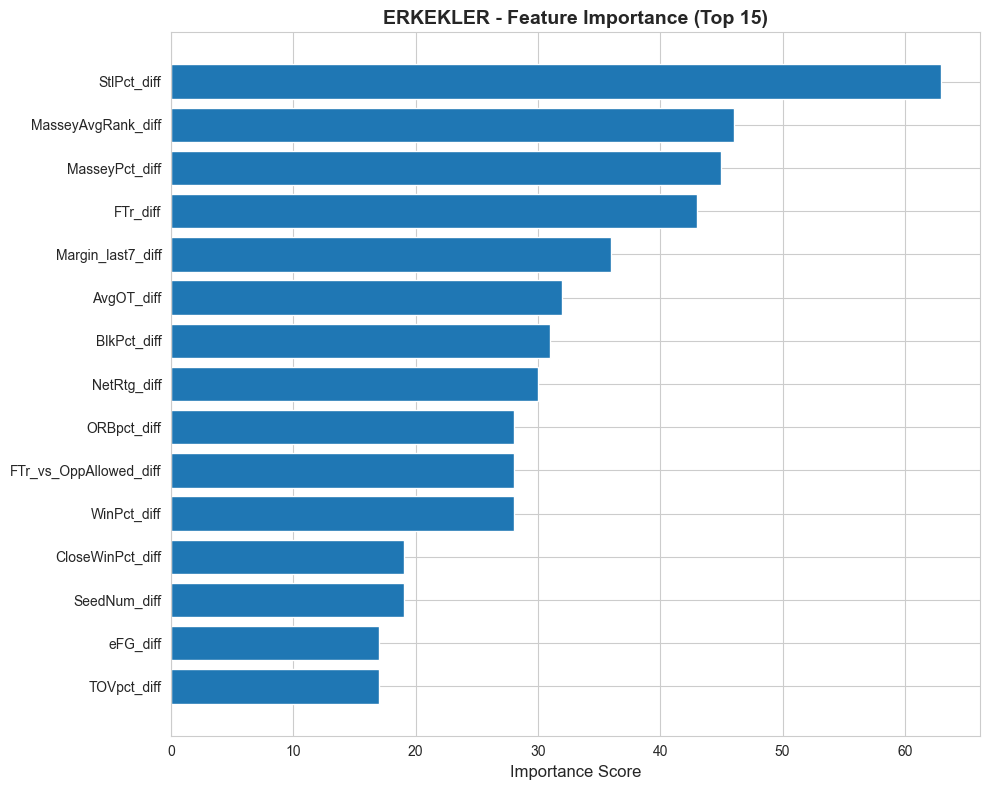


ERKEKLER - Top 15 Feature:
               Feature  Importance
           StlPct_diff          63
    MasseyAvgRank_diff          46
        MasseyPct_diff          45
              FTr_diff          43
     Margin_last7_diff          36
            AvgOT_diff          32
           BlkPct_diff          31
           NetRtg_diff          30
           ORBpct_diff          28
FTr_vs_OppAllowed_diff          28
           WinPct_diff          28
      CloseWinPct_diff          19
          SeedNum_diff          19
              eFG_diff          17
           TOVpct_diff          17

ERKEKLER - En ZayÄ±f 5 Feature (Drop adayÄ±):
                 Feature  Importance
     GamesLast7Days_diff           1
  ConfTourneyWinPct_diff           1
ConfTourneyChampion_diff           1
 DaysSinceConfFinal_diff           0
         ProgramAge_diff           0


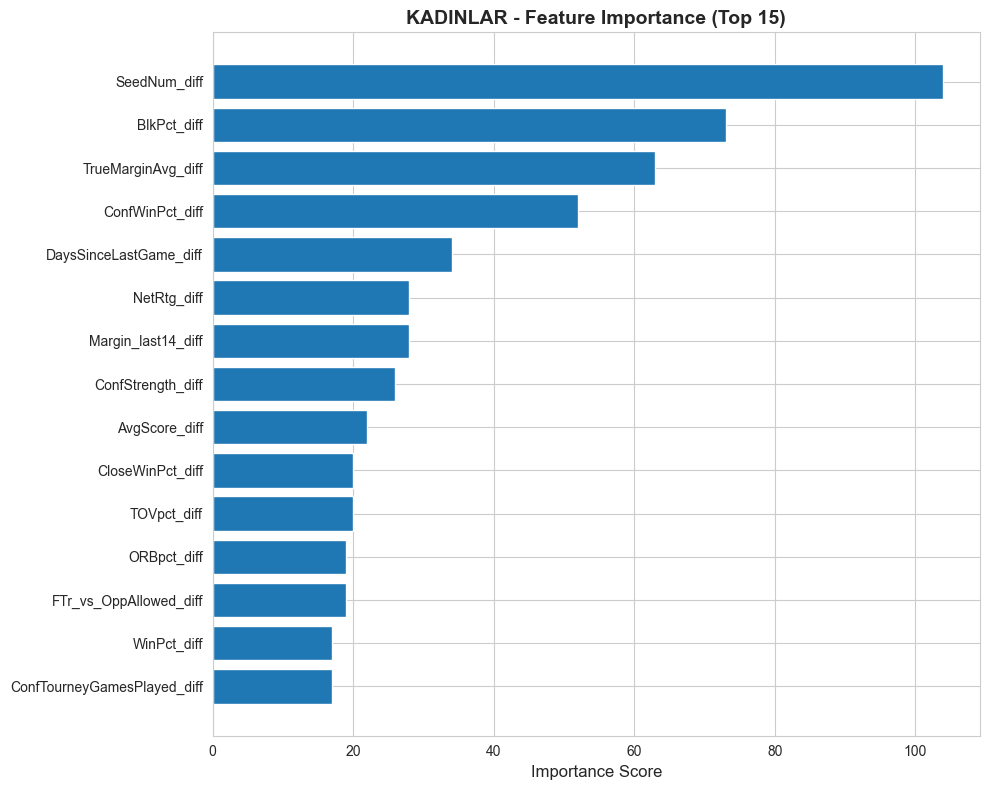


KADINLAR - Top 15 Feature:
                    Feature  Importance
               SeedNum_diff         104
                BlkPct_diff          73
         TrueMarginAvg_diff          63
            ConfWinPct_diff          52
     DaysSinceLastGame_diff          34
                NetRtg_diff          28
         Margin_last14_diff          28
          ConfStrength_diff          26
              AvgScore_diff          22
           CloseWinPct_diff          20
                TOVpct_diff          20
                ORBpct_diff          19
     FTr_vs_OppAllowed_diff          19
                WinPct_diff          17
ConfTourneyGamesPlayed_diff          17

KADINLAR - En ZayÄ±f 5 Feature (Drop adayÄ±):
                Feature  Importance
   GamesLast14Days_diff           3
     WinPct_last21_diff           1
      WinPct_last7_diff           1
    B2B_Last14Days_diff           1
DaysSinceConfFinal_diff           1


In [28]:
def plot_feature_importance(model, features, gender_label, top_n=15):
    """
    Feature importance grafiÄŸi Ã§izer.
    """
    # Importance verisi
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Top N
    top_features = importance_df.head(top_n)
    
    # Grafik
    plt.figure(figsize=(10, 8))
    plt.barh(top_features['Feature'], top_features['Importance'])
    plt.gca().invert_yaxis()
    plt.title(f'{gender_label} - Feature Importance (Top {top_n})', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Tablo
    print(f"\n{gender_label} - Top {top_n} Feature:")
    print(top_features.to_string(index=False))
    
    # En zayÄ±f 5 feature
    bottom_features = importance_df.tail(5)
    print(f"\n{gender_label} - En ZayÄ±f 5 Feature (Drop adayÄ±):")
    print(bottom_features.to_string(index=False))
    
    return importance_df

# Erkekler importance
men_importance = plot_feature_importance(men_model, features_m, "ERKEKLER", top_n=15)

# KadÄ±nlar importance
women_importance = plot_feature_importance(women_model, features_w, "KADINLAR", top_n=15)

## Cell 8: Prediction Calibration Analysis

Modelimiz overconfident mi? Yani "%90 kazanÄ±r" dediÄŸinde gerÃ§ekten %90 mÄ± kazanÄ±yor?

**Ä°yi kalibre edilmiÅŸ model:** Tahmin ettiÄŸi olasÄ±lÄ±k â‰ˆ GerÃ§ekleÅŸme oranÄ±


ERKEKLER - Kalibrasyon Analizi:
  Ortalama Kalibrasyon Error: -0.0030 âœ…

  Bin Analizi:
 Pred_Prob  Actual_Rate  Count
     0.179        0.167      6
     0.314        0.300     40
     0.510        0.500     48
     0.697        0.735     34
     0.821        0.833      6


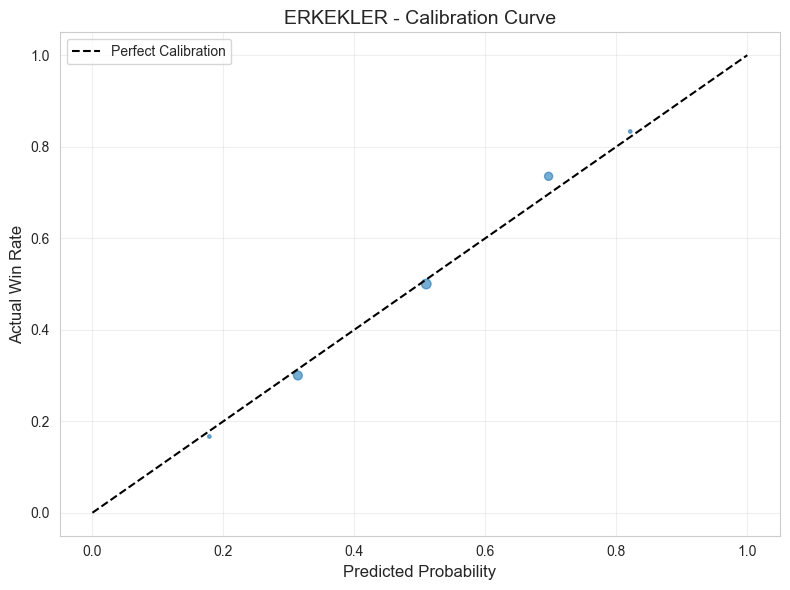


KADINLAR - Kalibrasyon Analizi:
  Ortalama Kalibrasyon Error: -0.0075 âœ…

  Bin Analizi:
 Pred_Prob  Actual_Rate  Count
     0.153        0.045     22
     0.318        0.333     24
     0.493        0.476     42
     0.672        0.708     24
     0.845        0.955     22


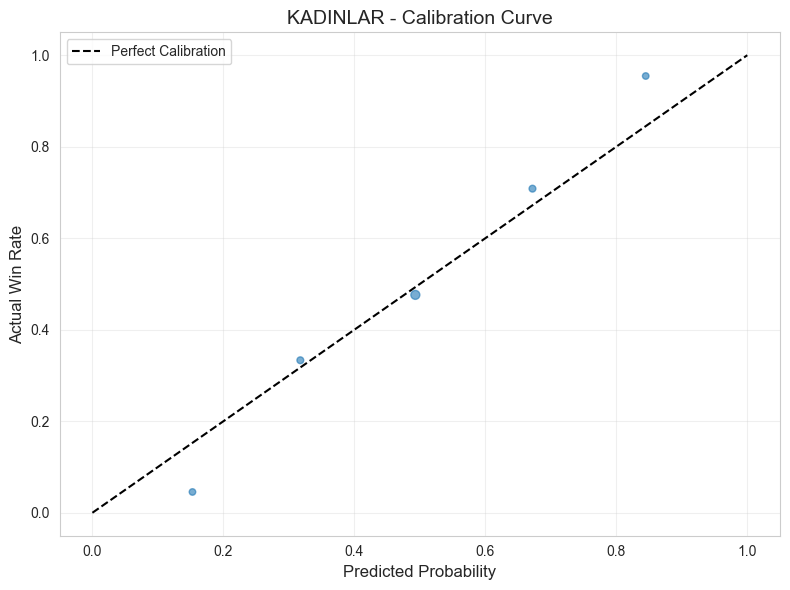

In [31]:
def analyze_calibration(y_true, y_pred_proba, gender_label, n_bins=5):
    """
    Model kalibrasyonunu analiz eder.
    """
    # Bins oluÅŸtur
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Her bin iÃ§in actual win rate hesapla
    actual_rates = []
    pred_rates = []
    counts = []
    
    for i in range(n_bins):
        mask = (y_pred_proba > bins[i]) & (y_pred_proba <= bins[i + 1])
        if mask.sum() > 0:
            actual_rates.append(y_true[mask].mean())
            pred_rates.append(y_pred_proba[mask].mean())
            counts.append(mask.sum())
    
    # DataFrame
    calib_df = pd.DataFrame({
        'Pred_Prob': pred_rates,
        'Actual_Rate': actual_rates,
        'Count': counts
    })
    
    # Kalibrasyon error (ortalama fark)
    calib_error = np.mean(np.array(calib_df['Pred_Prob']) - np.array(calib_df['Actual_Rate']))
    
    print(f"\n{gender_label} - Kalibrasyon Analizi:")
    print(f"  Ortalama Kalibrasyon Error: {calib_error:.4f} {'âœ…' if abs(calib_error) < 0.05 else 'âš ï¸'}")
    print(f"\n  Bin Analizi:")
    print(calib_df.round(3).to_string(index=False))
    
    # Grafik
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    plt.scatter(pred_rates, actual_rates, s=counts, alpha=0.6)
    plt.xlabel('Predicted Probability', fontsize=12)
    plt.ylabel('Actual Win Rate', fontsize=12)
    plt.title(f'{gender_label} - Calibration Curve', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return calib_df

# Erkekler kalibrasyon
men_calib = analyze_calibration(y_val_m, men_pred, "ERKEKLER")

# KadÄ±nlar kalibrasyon
women_calib = analyze_calibration(y_val_w, women_pred, "KADINLAR")

## Cell 9: SonuÃ§ Ã–zeti ve Model Kaydetme

In [33]:
import joblib
from datetime import datetime

# SonuÃ§ Ã¶zeti
results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'men': {
        'brier_score': men_brier,
        'log_loss': men_logloss,
        'auc': men_auc,
        'n_features': len(features_m),
        'n_estimators': men_model.n_estimators_
    },
    'women': {
        'brier_score': women_brier,
        'log_loss': women_logloss,
        'auc': women_auc,
        'n_features': len(features_w),
        'n_estimators': women_model.n_estimators_
    }
}

print("\n" + "="*60)
print("BASELINE MODEL EÄÄ°TÄ°MÄ° TAMAMLANDI!")
print("="*60)
print(f"\nZaman: {results['timestamp']}")
print(f"\nErkekler:")
print(f"  Brier Score: {men_brier:.4f}")
print(f"  AUC: {men_auc:.4f}")
print(f"  KullanÄ±lan aÄŸaÃ§: {men_model.n_estimators_}")
print(f"\nKadÄ±nlar:")
print(f"  Brier Score: {women_brier:.4f}")
print(f"  AUC: {women_auc:.4f}")
print(f"  KullanÄ±lan aÄŸaÃ§: {women_model.n_estimators_}")

# Modelleri kaydet
model_dir = '../artifacts/models'
import os
os.makedirs(model_dir, exist_ok=True)

joblib.dump(men_model, f'{model_dir}/men_baseline_model.pkl')
joblib.dump(women_model, f'{model_dir}/women_baseline_model.pkl')

print(f"\nâœ… Modeller kaydedildi: {model_dir}/")

# Feature listesini kaydet
with open(f'{model_dir}/men_features.txt', 'w') as f:
    f.write('\n'.join(features_m))
with open(f'{model_dir}/women_features.txt', 'w') as f:
    f.write('\n'.join(features_w))

print(f"âœ… Feature listeleri kaydedildi")


BASELINE MODEL EÄÄ°TÄ°MÄ° TAMAMLANDI!

Zaman: 2026-03-12 01:51:42

Erkekler:
  Brier Score: 0.2050
  AUC: 0.7454
  KullanÄ±lan aÄŸaÃ§: 24

KadÄ±nlar:
  Brier Score: 0.1777
  AUC: 0.8155
  KullanÄ±lan aÄŸaÃ§: 25

âœ… Modeller kaydedildi: ../artifacts/models/
âœ… Feature listeleri kaydedildi


## ğŸ“ Notlar ve Sonraki AdÄ±mlar

### BaÅŸarÄ± Kriterleri:
- âœ… **Brier Score < 0.20**: Ä°yi kalibre edilmiÅŸ
- âœ… **AUC > 0.75**: Ä°yi ayÄ±rt edicilik

### Sonraki Ä°yileÅŸtirme AdÄ±mlarÄ±:

1. **Feature Selection**: ZayÄ±f feature'larÄ± Ã§Ä±kar
   - Importance < 10 olanlarÄ± dÃ¼ÅŸÃ¼r
   - Yeniden eÄŸit, performans deÄŸiÅŸimi?

2. **Hyperparameter Tuning**: Optuna ile en iyi parametreleri bul
   ```python
   # learning_rate: [0.01, 0.1]
   # max_depth: [4, 10]
   # num_leaves: [15, 63]
   ```

3. **Probability Calibration**: Isotonic regression
   ```python
   from sklearn.calibration import CalibratedClassifierCV
   calibrated = CalibratedClassifierCV(model, method='isotonic')
   ```

4. **Ensemble Modelleri**:
   - LightGBM + XGBoost + Logistic Regression
   - Weighted average

5. **2026 Tahminleri**: Kaggle submission hazÄ±rla

### Hedefler:
- Kaggle Brier Score: < 0.18 (Top %10)
- Private leaderboard'da baÅŸarÄ±lÄ± ol